<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Introduction to Classical Statistics  <a class="tocSkip">

This notebook serves as a recap of the definitions in classical statistics, and it forms the basis upon which we build the rest of the terminology and tools we present during the school. Specifically, we will see:
    
- Conditional probabilities, dependent/independent events, marginalization
- Probability density and probability mass
- Cumulative probability functions

# Setup

In [1]:
import numpy as np
import scipy.stats as st
from scipy.optimize import minimize
import requests

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Working in:
/content/astrostat-school-8/Basic_Statistics

Content:
	 ['Basic_Statistics.ipynb', 'data', 'images']
Imported matplotlib.
Imported seaborn.
Plotting style set.


# 1. Probability

The fundamental concept in statistics is the probability, denoted as:

$$\Large P(A)$$

which represents the frequency of the occurance of an event $A$ (or our belief in a statement).

The basic property of a probability is that

$$\Large  0 \leq P(A) \leq 1 $$

where 0 is the value of an impossible event, while 1 that of a certain event!

## Probability calculus

1. In most cases, A is not certain. There is a scenario of A not happening. This event is "complementary" to A:

$$\Large  P(A^c) = P(\bar{A}) =  1 - P(A) $$

2. This can be extended to a series of alternative scenarios/events: A, B, C, ...

$$\Large  P(A) + P(B) + P(C) + \cdots = 1 $$

> Note that the events are alternatives: when one is true, the others are false!

3. Sum rule: the probability of either A or B happening is equal to the sum of the probabilities minus the probability of both happening:

$$\Large  P(A \cup B) = P(A \text{ or } B) = P(A) + P(B) - P(A \cap B) = P(A) + P(B) - P(A \text{ and } B)$$


<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Basic_Statistics/images/A_B.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=600><center><br>
        Figure 1. Example of logical relations between events (Venn diagram) and their corresponding probabilities. The "dimensions" of this abstract space where events A and B occur could be anything, e.g. space (2D, 3D), time (1D), or anything else (including combinations).<br></center></td></tr></table>

## Conditional probability

The probability of $A$ given $B$, is the probability of $A$ happening given that $B$ is true as well:

$$\Large  P(A | B) \quad \small \text{and the reverse} \Large \quad P(B|A)$$

which are not necessarily equal.

Take for example rain (event A) and cloudy weather (event B). The probability of rain when it's already cloudy, $P(A|B)$, is usually lower than the probability of clouds when it is already raining, $P(B|A)$.

> The conditional probability is useful to express dependencies between events.


## Factoring probabilities

The **joint** probability of $A$ and $B$ can be expressed using the conditional probability:

$$\Large P(A \small \text{ and } \Large B) =  P(A, B) = P(A|B) P(B)$$

which simply states that the probability of both $A$ and $B$ happening is equal to the probability of A given B, times the probability of $B$.

Again, as an example, think of the probability of rain when it is cloudy, multiplied by the probability of being cloudy.

> Factorization is a way to **break** the expressions into simpler, or more understood terms!

## Independence

If $A$ and $B$ are completely independent, i.e. whether $A$ is true or false has nothing to do with the state of $B$, then the conditional probability is equal to the probability of the event itself:

$$\Large  P(A | B) = P(A) $$

which simplifies the factorization:

$$\Large P(A, B) = P(A) P(B) $$

Think of the probability of flipping a coin and finding heads (or tails) on a rainy day.

> Independence is a useful property (or assumption) which simplifies probability terms and conditional probabilities.

## Marginalization

The probability of $A$ can be expressed as the probability of A and B plus the probability of A and not B:

$$\Large  P(A) = P(A, B) + P(A, \bar{B}).$$

Or if $B$ has multiple *mutually exclusive* and *exhaustive* outcomes $B_1$, $B_2$, $\dots$, $B_k$, such that $P(B_1)+P(B_2)+\cdots+P(B_k)=1$:

$$\Large  P(A) = \sum\limits_{i=1}^k P(A, B_i) $$

Rain can occur both when it is cloudy as well as when it is not and the total probablity of rain should reflect this (by a sum).

> Marginalization is a way to **introduce** other events / parameters / models in the probability of interest.

# 2. Continuous variables

## Probability density

What if we don't have distinct events, and our set is infinite?

This is typical of continuous variables, such as magnitude, color, distance, mass, etc.

Let's load SDSS data for white dwarfs of spectral type DB (no hydrogen but helium absoption lines, [Kleinman et al. 2013](https://arxiv.org/abs/1212.1222))

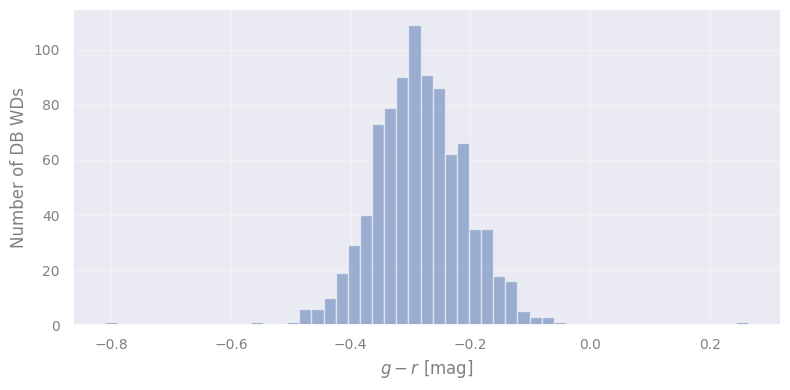

In [2]:
# let's get the data...
DB_WDs = np.load("data/DB_kleinman.npz")['a']
# ...and compute the g-r color
g_r = DB_WDs["g"] - DB_WDs["r"]

plt.hist(g_r, bins="fd", alpha=0.5)
plt.xlabel("$g-r$ [mag]")
plt.ylabel("Number of DB WDs")
plt.show()

**Question**

What is the probability of a DB WD to have $g-r = -0.3$?

In [6]:
# computing the fraction of values with g-r = -0.3
# find how many items match the value exactly
# mean provides their frequency, so the probability
print(f"P(g-r = {-0.3:.6f}) = {np.mean(g_r == -0.3):.4f}")

# equivalent to :
# print((g_r == -0.3).sum()/len(g_r))

P(g-r = -0.300000) = 0.0000


In [8]:
# finding the value closest to -0.3 and
# computing the fraction of the data having it
value_close_to_it = g_r[np.argmin(np.abs(g_r - (-0.3)))]
print(f"P(g-r = {value_close_to_it:.6f}) = {np.mean(g_r == value_close_to_it):.4f}")

# equivalent to
# print((g_r == value_close_to_it).sum()/len(g_r))
# or even:
# print( 1/ len(g_r))

P(g-r = -0.300028) = 0.0011


Consequently, for continuous $x$, the quantity $P(x)$ will always be 0! On the other hand, we can calculate the probabilities in a given range of values. For example, the probability of $g-r < -0.3$?

$$\Large P(g-r < -0.3)$$

In [7]:
# the fraction of colors less than -0.3
np.mean(g_r < -0.3)

np.float64(0.4198645598194131)

which is complementary to the alternative scenario, $g-r \geq -0.3$:

$$\Large P(g-r \geq -0.3)$$

In [9]:
# the fraction of colors greater or equal to -0.3
np.mean(g_r >= -0.3)

np.float64(0.5801354401805869)

Therefore, $P(x)$ can still be used as a **probability density** which is supposed to be multiplied by $dx$:

$$\Large  P(x) \; dx \simeq P(x < x' < x+\Delta x) \; \Delta x$$


(so, the correct statement is that *"$P(x)$ should go to zero as $\Delta x$ becomes infinitely small"*)


The total probability is therefore:

$$\Large \int\limits_{-\infty}^{+\infty} P(x)\,dx = 1 $$


From this, it's easy to see that...
> ..the probability density $P(x)$ should be in units of $x^{-1}$ (hence, it is a *density*)

Arguably the most famous and useful of all probability density functions is the **normal** or **Gaussian** distribution:

$$\Large f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp \left[ -\frac{\left(x-\mu\right)^2}{2\sigma^2} \right] $$

where $\mu$ and $\sigma$ are the mean value and standard deviation. If our data follow the normal distribution, then the sample mean and stadard deviation can be used to express the distribution function with this parametric formula!

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Exercise 1:**</font>    

**Objective:** Draw the sample and the corresponding normal distribution.

**Task:** It this exercise you are asked to fill in the missing code in order to plot a histogram of the sample along with a Gaussian distribution that best describes it. For this you need to perform the following:
    
1. Find the mean and the standard deviation of the sample (check [numpy's `np.mean`](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) and [`np.std`](https://numpy.org/doc/stable/reference/generated/numpy.std.html)).

2. Restrict the $x$ values within 5 sigmas around the mean.

3. Calculate the Gaussian PDF values.
    
4. Add the necessary quantities in the plot functions.    
</div>

In [11]:
sample_mean = np.mean(DB_WDs["g"] - DB_WDs["r"])
sample_std = np.std(DB_WDs["g"] - DB_WDs["r"])
print(sample_mean, sample_std)

-0.284704658013544 0.07806358346006693


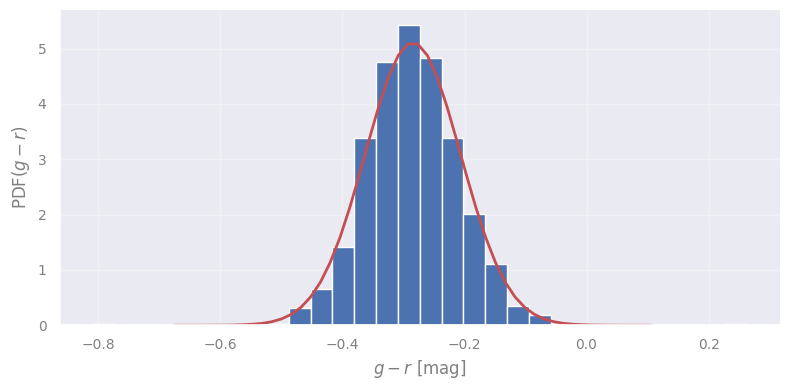

In [17]:
sample_mean = np.mean(g_r)
sample_std = np.std(g_r)

# let's plot 5 sigmas around the mean value...
x_values = np.linspace(sample_mean-(5*sample_std), sample_mean+(5*sample_std), 50)
# ...the Gaussian PDF
y_values = (1/np.sqrt(2*np.pi*sample_std**2))*np.exp((-1*(x_values-sample_mean)**2)/(2*sample_std**2))

plt.hist(g_r, bins=30, density=True)
plt.plot(x_values, y_values, "r-")
plt.xlabel("$g-r$ [mag]")
plt.ylabel("PDF($g-r$)")
plt.show()

In [18]:
plt.hist?

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
**Caution:** By default `plt.hist()` will use `density=False`, showing the aboslute numbers of events at each bin. To normalize this, so that is comparable to the total probability of 1 form the PDF, you need to change it to True.

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

Routines to find the mean and standard deviation:
<pre>
sample_mean = np.mean(g_r)
sample_std = np.std(g_r)
</pre>
    
Let's plot 5 sigmas around the mean value:
<pre>
x_values = np.linspace(sample_mean-5*sample_std, sample_mean+5*sample_std, 50)
</pre>

The Gaussian PDF:
<pre>
y_values = 1 / np.sqrt(2*np.pi*sample_std**2.0) * np.exp(-(x_values-sample_mean)**2.0/(2*sample_std**2.0))
</pre>

Defining some plotting optiions:
<pre>
plt.hist(g_r, bins=30, density=True)
plt.plot(x_values, y_values, "r-")
</pre>
    
</details>
</div>

## Common Probability Density Functions (PDFs)

In `scipy.stats` we can find most of the popular distributions, providing functions to calculate the PDF, PMF (see below), and even $\log$-versions of them that are optimized for accuracy when small numbers are expected. Let's first check the simplest example of the Gaussian distribution, using the methods from this library.

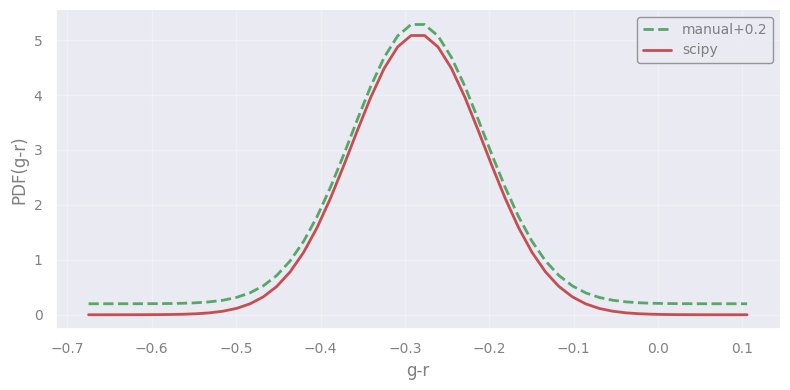

In [19]:
import scipy.stats as st

# taking the PDF of a Gaussian distribution
pdf = st.norm.pdf(x_values, loc=sample_mean, scale=sample_std)

# comparing with our "manual" PDF
offset = 0.2
plt.plot(x_values, y_values+offset, "g--", label=f"manual+{offset}" )
plt.plot(x_values, pdf, "r-", label="scipy")
plt.xlabel('g-r')
plt.ylabel('PDF(g-r)')
plt.legend()
plt.show()

Let's take a look in a number of distributions:

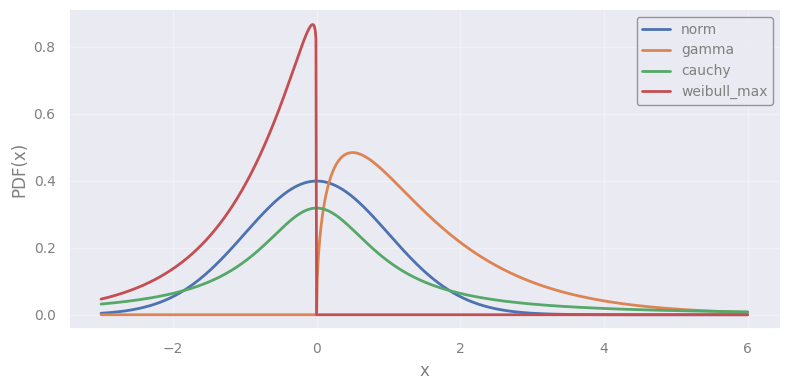

In [20]:
x_points = np.linspace(-3, 6.0, 1000)

# various distributions to try
distributions = [
    st.norm(),
    st.gamma(1.5),
    st.cauchy(),
    st.weibull_max(1.05),
]

for distribution in distributions:
    pdf = distribution.pdf(x_points)
    plt.plot(x_points, pdf, label=distribution.dist.name, lw=2)
plt.legend(loc="upper right")
plt.ylabel("PDF(x)")
plt.xlabel("x")
plt.show()

## The Cumulative Distribution Function (CDF)

Simply, the probability of "less than a value":

$$\Large F(x) = \int\limits_{-\infty}^{x} f(x')\,dx'$$

where $f(x)$ is the probability density function.

> The CDF is useful for finding confidence intervals: 50% chance of your event in the range from $x_1$ to $x_2$ (see lecture on Hypothesis Testing).

Let's see how it looks by using the previous set of distributions:

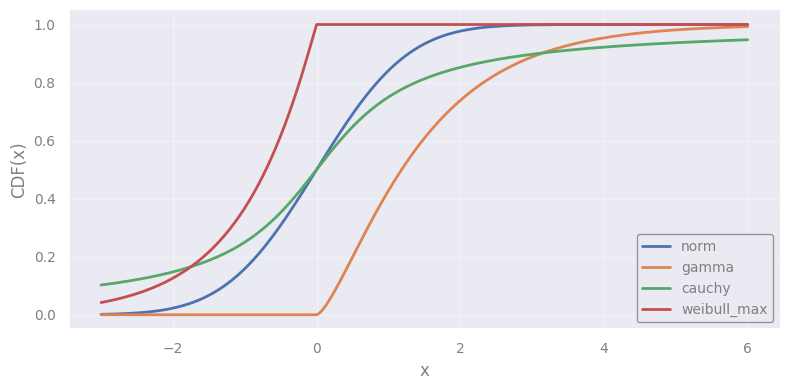

In [21]:
for distribution in distributions:
    cdf = distribution.cdf(x_points)
    plt.plot(x_points, cdf, label=distribution.dist.name, lw=2)
plt.legend(loc="lower right")
plt.ylabel("CDF(x)")
plt.xlabel("x")
plt.show()

Notice the difference between the various distibutions (e.g. for a population following the Weibull distribution the peak is achieved much faster rather than the Gamma one).

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Exercise 2:**</font>    

**Objective:** Draw the sample and the corresponding normal cumulative distributions.

**Task:** Similar to the previous exercise, fill in the missing code in order to plot the CDFs for the sample and its corresponding Gaussian distribution.
    
> TIP: Use the option `cumulative=1` for the `plt.hist()` converts automatically the plot. </div>

-0.284704658013544 0.07806358346006693


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

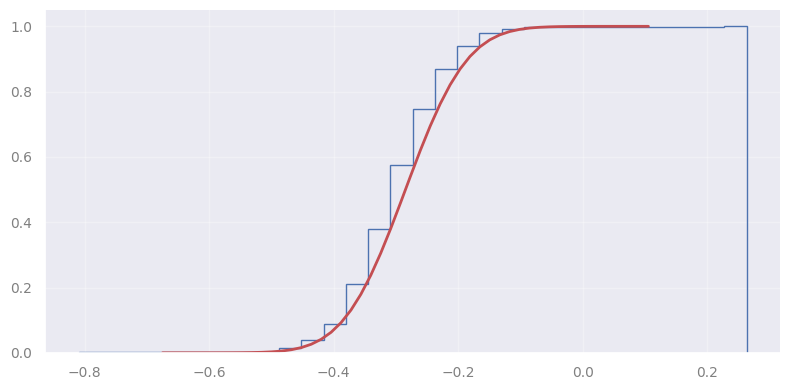

In [32]:

from scipy import integrate

sample_mean = np.mean(g_r)
sample_std = np.std(g_r)

print(sample_mean, sample_std)
# let's plot 5 sigmas around the mean value...
x_values = np.linspace(sample_mean-(5*sample_std), sample_mean+(5*sample_std), 50)

# ...the Gaussian CDF
#pdf = st.norm.pdf(x_values, loc=sample_mean, scale=sample_std)
cdf = st.norm.cdf(x_values, loc=sample_mean, scale=sample_std)

def f(t): #try to integrate pdf by hand to compare result with library
    return (1/np.sqrt(2*np.pi*sample_std**2))*np.exp((-1*(x-sample_mean)**2)/(2*sample_std**2))

def F(x):
    # integrate f(t) from t=0 to t=x
    result, error = integrate.quad(f, -np.inf, x)
    return result

f_x = lambda x: (1/np.sqrt(2*np.pi*sample_std**2))*np.exp((-1*(x-sample_mean)**2)/(2*sample_std**2))
cdf2 = integrate.quad(f_x, -np.inf, np.inf)


plt.hist(g_r, bins=30, density=True,
         cumulative = 1, histtype="step", label="Data")
plt.plot(x_values, cdf, "r-", label='CDF')
plt.plot(x_values, F(x_values), "r-", label='CDF')

plt.xlabel('g-r')
plt.ylabel('CDF(g-r)')
plt.show()

(1.0, 6.279738551014053e-09)

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  
  
    
See the previous exercise for some elements of this solution.

The Gaussian CDF:
<pre>
cdf = st.norm.cdf(x_values, loc=sample_mean, scale=sample_std)
</pre>

Defining some plotting options:
<pre>
plt.hist(g_r, bins=30, density=True, cumulative=1, histtype="step", label="Data")
plt.plot(x_values, cdf, "r-", label='CDF')
</pre>
    
</details>
</div>

# 3. Discrete variables

## Probability Mass Function (PMF)

Let's go back to the discrete case! Events A, B, etc do not necessarily have an order but there are cases where order matters, e.g. in counting experiments. For example, the numbers of astronomical objects in a certain galaxy/volume/region in Milky Way, or the photon counts in high energy astrophysics, are Poisson-distributed.

Let's plot the probability of getting 0, 1, ..., N counts when the mean photon count is known (assuming Poisson distribution). We will use the `.pmf()` method.

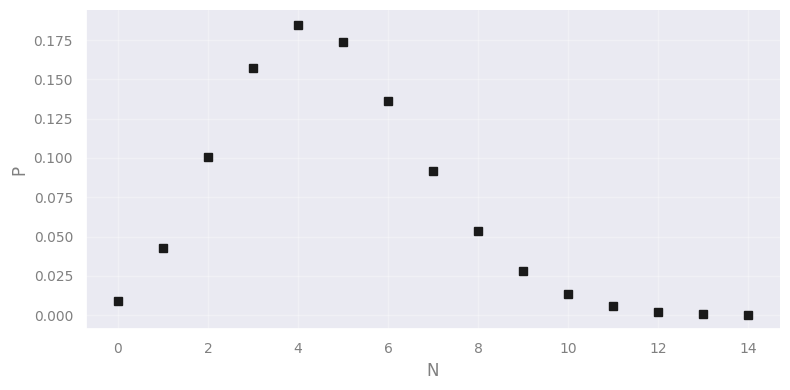

In [33]:
mean_photon_count = 4.7
distribution = st.poisson(mean_photon_count)

photon_counts = np.arange(0, mean_photon_count*3)
photon_pmf = distribution.pmf(photon_counts)

plt.plot(photon_counts, photon_pmf, "ks")
plt.xlabel('N')
plt.ylabel('P')
plt.show()

This is not a probability density any more. We have a measurable probability for 0, 1, 2, 3, ... photons! We often use indices to signify the discrete integer values of such *probability mass functions*:

$$ \Large \sum\limits_{k=0}^{\infty} P(k) = 1 $$

> *"Probability mass"* is a term used in analogy to *"probability density"* because the latter cannot be defined for discrete variables.

Let's test this with the values in the plot:

In [34]:
sum(photon_pmf)

np.float64(0.9998822825234644)

## CDF of discrete distributions

The cumulative distribution function is always an integral even if the variable is discrete.

However, because of the discrete nature of the probability mass function, it's a **discontinuous** function:

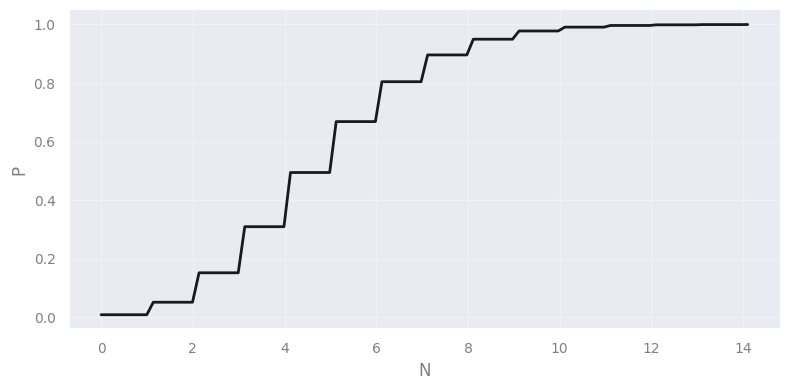

In [35]:
mean_photon_count = 4.7
distribution = st.poisson(mean_photon_count)


xx = np.linspace(0, mean_photon_count*3, 100)
photon_cdf = distribution.cdf(xx)

plt.plot(xx, photon_cdf, "k-")
plt.xlabel('N')
plt.ylabel('P')
plt.show()

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Exercise 3:**</font>    

**Objective:** Working with probability density/mass functions

**Task:** In this exercise you are asked to fill in the missing code in order to plot a sample from a specific distribution (two options) and calculate various characteristic properties. More specifically:
    
1. Make a sample of 10000 points from the distribution </br>(*hint:* use the [.rvs()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.sampling.TransformedDensityRejection.rvs.html#rvs) method, that generates random samples from a distribution). Plot the sample using a histogram.

2. Make and plot the pdf and cdf of the distribution.

3. Calculate the mean, median, standard deviation of the distribution.

4. Calculate the 5% percentile <br>
(*hint:* use the [.ppf()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.ppf.html#ppf) method, that finds the point of the distribution that satisfies the given percent).

5. Find the 68% Confidence Interval<br>
(*hint:* use the [.interval()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.interval.html#interval) method)

</div>


In [ ]:
# the plotting range (your random variable, in some units)
x_points = np.linspace(0.0, 4.0, 300)

# dist = st.norm(2.0, 0.35)

# the Fisk (or lof-logistic) distribution to use,
# check https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.fisk.html
dist = st.fisk(2.5)

# draw a (large) sample from the distribution
sample = ...

# calculate the PDF in the plotting range
pdf = ...

# calculate the CDF in the plotting range
cdf = ...

# compute the mean, median, and standard deviation
mean = ...
median = ...
std = ...

# find the 5% percentile, and the 68% confidence interval
p05 = ...
lo68, hi68 = ...

# search for the maximum of the distribution (mode)
mode = minimize(lambda x: -dist.pdf(x), x0=median).x


# report what we found

print(f"Standard deviation: {std:.4f}")

plt.figure()
plt.hist(..., bins="fd", density=True,
         histtype="step", color="b", lw=1, label="Sample")
plt.plot(..., ..., "k-", lw=2, label="PDF")
plt.plot(..., ..., "k:", lw=2, label="CDF")
plt.axvspan(..., ..., color="m", alpha=0.3, ec="none", label="68% CI")
plt.axvline(..., color="k", ls="-", lw=4, label="Mode")
plt.axvline(..., color="r", ls="-", lw=3, label="Mean")
plt.axvline(..., color="g", lw=2, label="Median")
plt.axvline(..., color="m", label="5% percentile")
plt.legend(loc="center right")
plt.xlabel('x [in some units]')
plt.ylabel('PDF')
plt.xlim(0.0, 4.0)
plt.ylim(ymin=0.0)
plt.show()

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  
  
    
Draw a (large) sample from the distribution:
<pre>
sample = dist.rvs(size=10000)
</pre>

Calculate the PDF in the plotting range:
<pre>
pdf = dist.pdf(x_points)
</pre>

Calculate the CDF in the plotting range:
<pre>
cdf = dist.cdf(x_points)
</pre>

Compute the mean, median, and standard deviation:
<pre>
mean = dist.mean()
median = dist.median()
std = dist.std()
</pre>

Find the 5% percentile, and the 68% confidence interval:
<pre>
p05 = dist.ppf(0.05)
lo68, hi68 = dist.interval(0.68)
</pre>

Defining some plotting options:
<pre>
plt.hist(sample, bins="fd", density=True, histtype="step", color="b", lw=1, label="Sample")
plt.plot(x_points, pdf, "k-", lw=2, label="PDF")
plt.plot(x_points, cdf, "k:", lw=2, label="CDF")
plt.axvspan(lo68, hi68, color="m", alpha=0.3, ec="none", label="68% CI")
plt.axvline(mode, color="k", ls="-", lw=4, label="Mode")
plt.axvline(mean, color="r", ls="-", lw=3, label="Mean")
plt.axvline(median, color="g", lw=2, label="Median")
plt.axvline(p05, color="m", label="5% percentile")
</pre>

</details>
</div>

Notice that when the distribution is not symmetric:
1. The confidence intervals correspond to regions with different probability density - the wings or edges of the distribution. These are not necessarily regions of high probability.
2. The "mode" is the most probable value. Typically we search for this value in many statistical applications but it is not given by standard functions (e.g., unlike the mean).
3. Knowing the distribution of your data, statistics, etc., and knowing how to work with it can make a huge difference!

In [ ]:
# EOF